In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cardekho_dataset.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [3]:
df.shape

(15411, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [5]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [6]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [7]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

ValueError: could not convert string to float: 'Maruti Alto'

In [69]:
numeric_df = df.select_dtypes(include=['int64','float64'])
numeric_df.head()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
0,0,9,120000,19.70,796,46.30,5,120000
1,1,5,20000,18.90,1197,82.00,5,550000
2,2,11,60000,17.00,1197,80.00,5,215000
3,3,9,37000,20.92,998,67.10,5,226000
4,4,6,30000,22.77,1498,98.59,5,570000


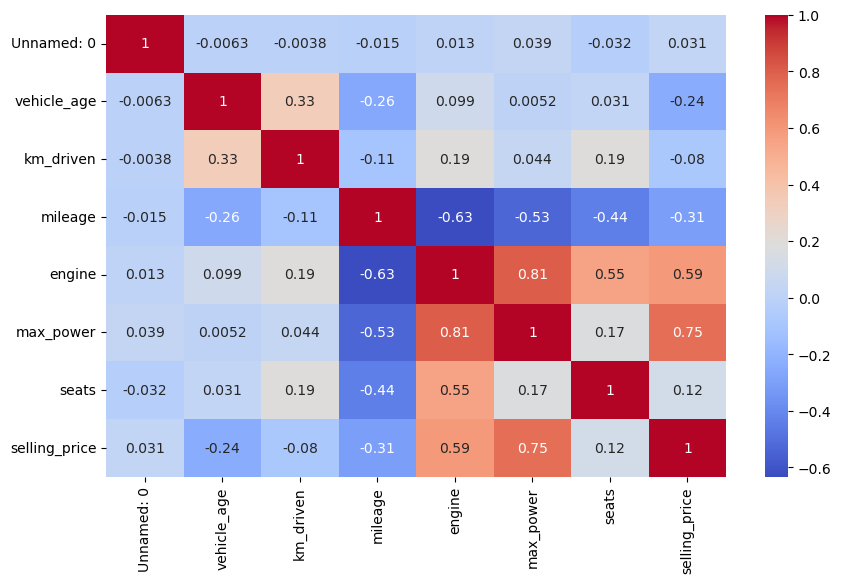

In [70]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [71]:
df.drop("Unnamed: 0", axis=1, inplace=True)

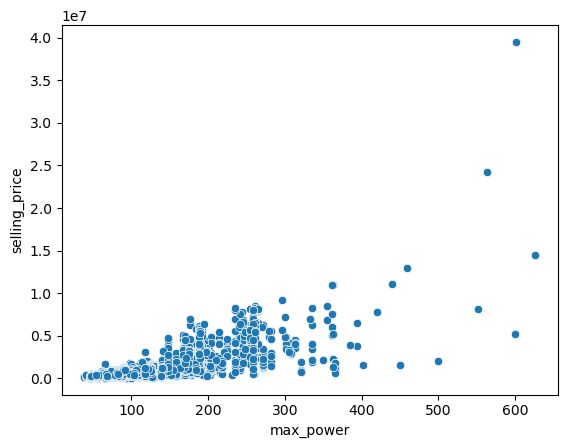

In [72]:
sns.scatterplot(x="max_power", y="selling_price", data=df)
plt.show()

In [74]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("Column:", col)
    print(df[col].unique())
    print()

In [75]:
df.columns

Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'selling_price', 'brand_BMW', 'brand_Bentley', 'brand_Datsun',
       ...
       'model_i10', 'model_i20', 'model_redi-GO', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'fuel_type_Diesel',
       'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol',
       'transmission_type_Manual'],
      dtype='object', length=164)

In [76]:
df.drop(['car_name'], axis=1, inplace=True)

KeyError: "['car_name'] not found in axis"

In [131]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [132]:
df = pd.get_dummies(df, drop_first=True)

In [133]:
df.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Bentley,brand_Datsun,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,550000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,215000,False,False,False,...,False,True,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,226000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,570000,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [77]:
df.shape

(15411, 164)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Columns: 164 entries, vehicle_age to transmission_type_Manual
dtypes: bool(157), float64(2), int64(5)
memory usage: 3.1 MB


In [79]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [81]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12328, 163)
X_test: (3083, 163)
y_train: (12328,)
y_test: (3083,)


In [82]:
#1.model(linear regression)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [83]:
y_pred = model.predict(X_test)

In [84]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
3334,190000,7.125788e+04
10928,600000,6.151970e+05
2518,665000,6.254916e+05
11322,1570000,1.222561e+06
9394,160000,-5.582842e+04
13649,675000,4.326672e+05
11892,465000,3.197938e+05
5133,260000,2.524556e+05
1611,300000,3.601658e+05
8137,850000,1.837191e+06


In [85]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 177718.4716402318
MSE: 150539582029.7024
RMSE: 387994.30669753696
R2 Score: 0.8000222854313845


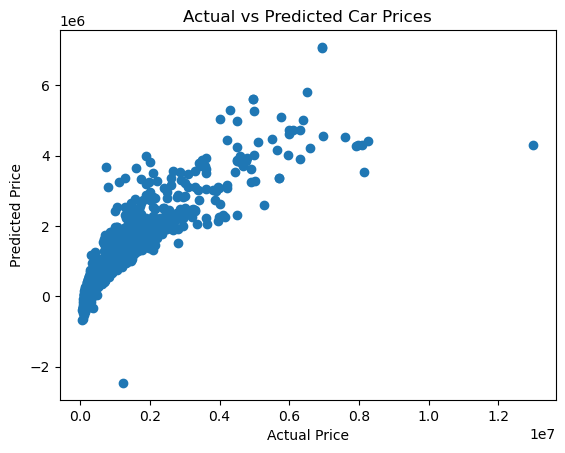

In [86]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [87]:
#2.model(ridge regression)

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

Ridge()

In [88]:
y_pred_ridge = ridge_model.predict(X_test)

In [89]:
mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 186114.62415710115
RMSE: 394583.75140485674
R2 Score: 0.7931720203104426


In [90]:
#3.model(lasso Regression)
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.422e+14, tolerance: 9.998e+11
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.1)

In [91]:
y_pred_lasso = lasso_model.predict(X_test)

In [92]:
mae = mean_absolute_error(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 178528.2264640081
RMSE: 391638.3112880831
R2 Score: 0.7962483035487258


In [93]:
import numpy as np

np.sum(lasso_model.coef_ == 0)

np.int64(11)

In [94]:
#4.model(elastic Net)

from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic_model.fit(X_train, y_train)

y_pred_elastic = elastic_model.predict(X_test)

In [95]:
mae = mean_absolute_error(y_test,y_pred_elastic)
mse = mean_squared_error(y_test, y_pred_elastic)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_elastic)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 247410.08379010254
RMSE: 475461.9692827531
R2 Score: 0.6996950682227268


In [96]:
#5.model(Decision tree regressor)
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [97]:
y_pred_dt = dt_model.predict(X_test)

In [98]:
mae = mean_absolute_error(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2 = r2_score(y_test, y_pred_dt)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 122992.47756514217
RMSE: 293573.8211210299
R2 Score: 0.8855105296950925


In [99]:
#6.mode(Random Forest Regressor)
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [100]:
y_pred_rf = rf_model.predict(X_test)

In [101]:
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 98970.16600944195
RMSE: 214527.8377299819
R2 Score: 0.9388638331281102


In [102]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

max_power              0.655706
vehicle_age            0.131474
km_driven              0.052066
mileage                0.035894
engine                 0.025209
brand_Ferrari          0.020519
model_GTC4Lusso        0.016291
brand_Rolls-Royce      0.008591
brand_Bentley          0.003920
brand_Mercedes-Benz    0.003831
dtype: float64

In [103]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [104]:
y_pred_gb = gb_model.predict(X_test)

In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 127016.62809164796
RMSE: 242555.52191057586
R2 Score: 0.9218456371380251


In [106]:
import sys
print(sys.version)

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


In [107]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [108]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [109]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [110]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [111]:
y_pred_xgb = xgb_model.predict(X_test)

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 99480.5546875
RMSE: 247351.12429095607
R2 Score: 0.9187246561050415


In [113]:
import sys
!{sys.executable} -m pip install lightgbm --user

In [114]:
from lightgbm import LGBMRegressor

In [115]:
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [116]:
lgb_model = LGBMRegressor(random_state=42)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 12328, number of used features: 97
[LightGBM] [Info] Start training from score 772120.619727


LGBMRegressor(random_state=42)

In [117]:
y_pred_lgb = lgb_model.predict(X_test)

In [118]:
mae = mean_absolute_error(y_test, y_pred_lgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2 = r2_score(y_test, y_pred_lgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 103502.1543345704
RMSE: 225154.5194856838
R2 Score: 0.932657035165146


In [119]:
import sys
!{sys.executable} -m pip install catboost --user

In [121]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

In [122]:
y_pred_cat = cat_model.predict(X_test)

In [123]:
mae = mean_absolute_error(y_test, y_pred_cat)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2 = r2_score(y_test, y_pred_cat)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 92528.02723356942
RMSE: 180739.0953596019
R2 Score: 0.9566054585746041


In [134]:
params = cat_model.get_all_params()

print("Iterations:", params['iterations'])
print("Learning Rate:", params['learning_rate'])
print("Depth:", params['depth'])

Iterations: 1000
Learning Rate: 0.060888998210430145
Depth: 6


In [124]:
from sklearn.metrics import r2_score

train_pred = cat_model.predict(X_train)
test_pred = cat_model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train R2: 0.9827408527549533
Test R2: 0.9566054585746041


In [125]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor

cat = CatBoostRegressor(random_state=42, verbose=0)

param_grid = {
    'iterations': [200, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8]
}

grid = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'depth': 6, 'iterations': 500, 'learning_rate': 0.1}
Best CV Score: 0.8572569950791092


In [126]:
best_cat_model = grid.best_estimator_

In [127]:
y_pred_best = best_cat_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 95027.76008036308
RMSE: 183168.12909813135
R2 Score: 0.9554312233087178


#Get Feature Importance from CatBoost

In [128]:
import pandas as pd

feature_importance = cat_model.get_feature_importance()

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
4,max_power,50.171928
0,vehicle_age,22.849828
1,km_driven,6.575675
3,engine,5.447451
2,mileage,2.182339
86,model_GTC4Lusso,1.149724
26,brand_Mercedes_Benz,1.135960
9,brand_Ferrari,1.086738
162,transmission_type_Manual,0.821049
158,fuel_type_Diesel,0.735154


In [129]:
import joblib
joblib.dump(cat_model, "car_price_model.pkl")

['car_price_model.pkl']

In [130]:
joblib.dump(X_train.columns, "features.pkl")

['features.pkl']